In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
df=pd.read_csv("/content/Walmart DataSet.csv")

In [ ]:
df

,Store,Date,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
0,1,05-02-2010,1643690.90,0,42.31,2.572,211.096358,8.106
1,1,12-02-2010,1641957.44,1,38.51,2.548,211.242170,8.106
2,1,19-02-2010,1611968.17,0,39.93,2.514,211.289143,8.106
3,1,26-02-2010,1409727.59,0,46.63,2.561,211.319643,8.106
4,1,05-03-2010,1554806.68,0,46.50,2.625,211.350143,8.106
...,...,...,...,...,...,...,...,...
6430,45,28-09-2012,713173.95,0,64.88,3.997,192.013558,8.684
6431,45,05-10-2012,733455.07,0,64.89,3.985,192.170412,8.667
6432,45,12-10-2012,734464.36,0,54.47,4.000,192.327265,8.667
6433,45,19-10-2012,718125.53,0,56.47,3.969,192.330854,8.667


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6435 entries, 0 to 6434
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Store         6435 non-null   int64  
 1   Date          6435 non-null   object 
 2   Weekly_Sales  6435 non-null   float64
 3   Holiday_Flag  6435 non-null   int64  
 4   Temperature   6435 non-null   float64
 5   Fuel_Price    6435 non-null   float64
 6   CPI           6435 non-null   float64
 7   Unemployment  6435 non-null   float64
dtypes: float64(5), int64(2), object(1)
memory usage: 402.3+ KB


In [ ]:
df.describe()

,Store,Weekly_Sales,Holiday_Flag,Temperature,Fuel_Price,CPI,Unemployment
count,6435.000000,6.435000e+03,6435.000000,6435.000000,6435.000000,6435.000000,6435.000000
mean,23.000000,1.046965e+06,0.069930,60.663782,3.358607,171.578394,7.999151
std,12.988182,5.643666e+05,0.255049,18.444933,0.459020,39.356712,1.875885
min,1.000000,2.099862e+05,0.000000,-2.060000,2.472000,126.064000,3.879000
25%,12.000000,5.533501e+05,0.000000,47.460000,2.933000,131.735000,6.891000
50%,23.000000,9.607460e+05,0.000000,62.670000,3.445000,182.616521,7.874000
75%,34.000000,1.420159e+06,0.000000,74.940000,3.735000,212.743293,8.622000
max,45.000000,3.818686e+06,1.000000,100.140000,4.468000,227.232807,14.313000


In [ ]:
df.isnull().sum()

,0
Store,0
Date,0
Weekly_Sales,0
Holiday_Flag,0
Temperature,0
Fuel_Price,0
CPI,0
Unemployment,0


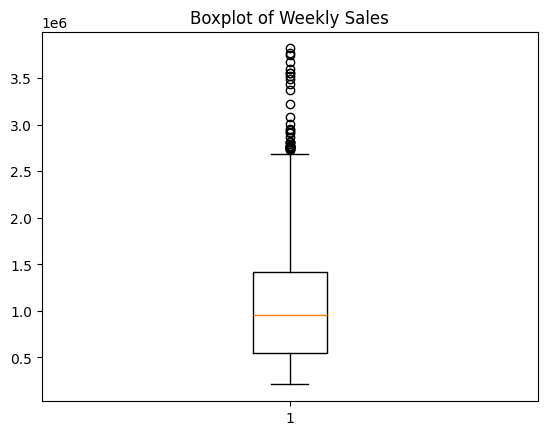

In [ ]:
plt.boxplot(df['Weekly_Sales'])
plt.title("Boxplot of Weekly Sales")
plt.show()

Not Removing outliers because it will affect the seasonal trends

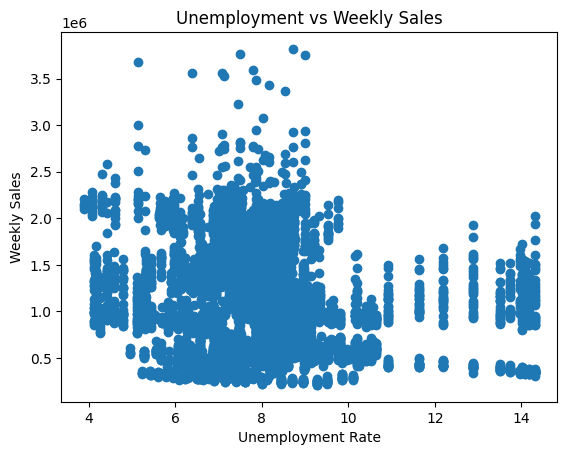

In [ ]:
import matplotlib.pyplot as plt

plt.scatter(df['Unemployment'], df['Weekly_Sales'])
plt.xlabel("Unemployment Rate")
plt.ylabel("Weekly Sales")
plt.title("Unemployment vs Weekly Sales")
plt.show()

#a) Are weekly sales affected by unemployment? If yes, which stores suffer most?

In [ ]:
df['Weekly_Sales'].corr(df['Unemployment'])

np.float64(-0.10617608965795429)

The correlation between unemployment and weekly sales is -0.106, indicating a very weak negative relationship. This suggests that unemployment does not have a significant impact on weekly sales across stores.

In [ ]:
store_data = df.groupby('Store')[['Weekly_Sales', 'Unemployment']].mean()

store_data.sort_values(by='Weekly_Sales')

,Weekly_Sales,Unemployment
Store,,
33,2.598617e+05,8.533154
44,3.027489e+05,6.735622
5,3.180118e+05,6.295406
36,3.735120e+05,7.869049
38,3.857317e+05,13.116483
3,4.027044e+05,7.176986
30,4.385796e+05,7.623846
37,5.189003e+05,7.869049
16,5.192477e+05,6.477993


In [ ]:
store_data = df.groupby('Store')[['Weekly_Sales', 'Unemployment']].mean()

sorted_data = store_data.sort_values(by='Weekly_Sales').reset_index()

sorted_data.head(10)

,Store,Weekly_Sales,Unemployment
0,33,259861.692028,8.533154
1,44,302748.866014,6.735622
2,5,318011.810490,6.295406
3,36,373511.992797,7.869049
4,38,385731.653287,13.116483
5,3,402704.441049,7.176986
6,30,438579.616224,7.623846
7,37,518900.281958,7.869049
8,16,519247.730070,6.477993
9,29,539451.428741,9.806385


The correlation between unemployment and weekly sales is -0.106, indicating a very weak negative relationship. This suggests that unemployment does not significantly impact sales. However, stores such as Store 33 and Store 38, which exhibit relatively low sales and higher unemployment rates, appear to be more affected compared to others. Overall, the impact is minimal and not strongly consistent across all stores.

##b. If the weekly sales show a seasonal trend, when and what could be the reason?

In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%d-%m-%Y')

df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

In [ ]:
monthly_sales = df.groupby('Month')['Weekly_Sales'].mean()
monthly_sales

,Weekly_Sales
Month,
1,9.238846e+05
2,1.053200e+06
3,1.013309e+06
4,1.026762e+06
5,1.031714e+06
6,1.064325e+06
7,1.031748e+06
8,1.048017e+06
9,9.893353e+05


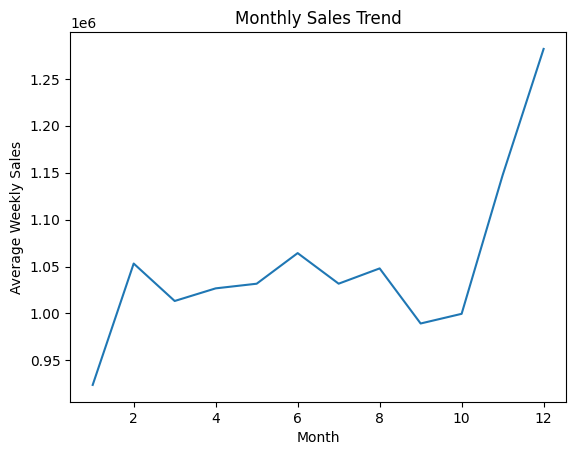

In [ ]:
monthly_sales.plot(kind='line')
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Average Weekly Sales")
plt.show()

The analysis of monthly sales indicates a clear seasonal trend. Sales peak in December (Month 12), which can be attributed to holiday seasons, festive shopping, and promotional offers. Conversely, sales are lowest in January (Month 1), likely due to reduced consumer spending after the holiday season. This pattern highlights strong seasonality in retail sales behavior.

#c. Does temperature affect the weekly sales in any manner?

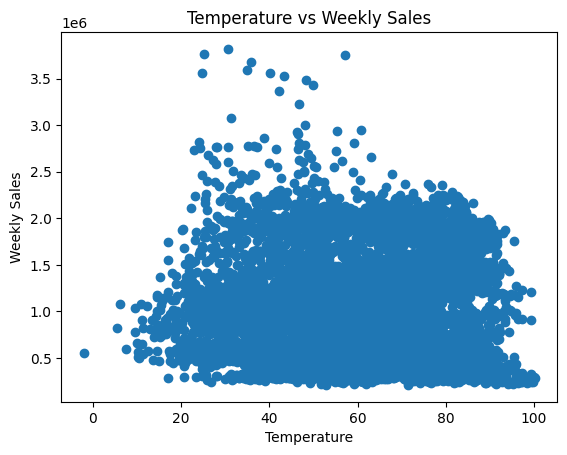

In [ ]:
plt.scatter(df['Temperature'], df['Weekly_Sales'])
plt.xlabel("Temperature")
plt.ylabel("Weekly Sales")
plt.title("Temperature vs Weekly Sales")
plt.show()

In [ ]:
df['Weekly_Sales'].corr(df['Temperature'])

np.float64(-0.06381001317946956)

The analysis indicates that temperature has minimal impact on weekly sales. The correlation value of -0.064 suggests a very weak negative relationship, and the scatter plot shows no clear trend between temperature and sales. Therefore, temperature does not significantly influence weekly sales.

#d. How is the Consumer Price index affecting the weekly sales of various stores?

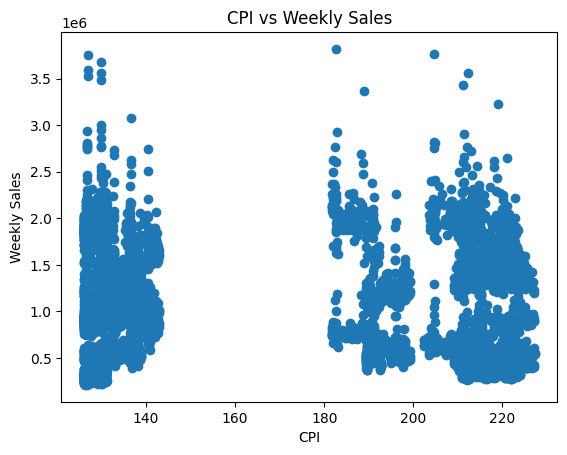

In [ ]:
plt.scatter(df['CPI'], df['Weekly_Sales'])
plt.xlabel("CPI")
plt.ylabel("Weekly Sales")
plt.title("CPI vs Weekly Sales")
plt.show()

In [ ]:
df['Weekly_Sales'].corr(df['CPI'])

np.float64(-0.07263416204017631)

The correlation between CPI and weekly sales is -0.073, indicating a very weak negative relationship. The scatter plot shows no clear pattern between CPI and sales. Therefore, CPI does not significantly affect weekly sales across stores.

#e. Top performing stores according to the historical data

In [ ]:
top_stores = df.groupby('Store')['Weekly_Sales'].mean().sort_values(ascending=False)

top_stores.head(5)

,Weekly_Sales
Store,
20,2.107677e+06
4,2.094713e+06
14,2.020978e+06
13,2.003620e+06
2,1.925751e+06


The top-performing stores based on average weekly sales are Store 20, Store 4, and Store 14, followed by Store 13 and Store 2. These stores consistently achieve higher sales compared to others, indicating strong performance. This may be due to factors such as favorable location, higher customer demand, or efficient inventory and operational management.

#f. The worst performing store, and how significant is the difference between the highest and lowest performing stores.

In [ ]:
store_sales = df.groupby('Store')['Weekly_Sales'].mean().sort_values()

store_sales.tail(1)   # best store

,Weekly_Sales
Store,
20,2.107677e+06


In [ ]:
store_sales.head(1)   # worst store

,Weekly_Sales
Store,
33,259861.692028


In [ ]:
store_sales = df.groupby('Store')['Weekly_Sales'].mean().sort_values()

best = store_sales.max()
worst = store_sales.min()

difference = best - worst
difference

1847815.1783216782

The worst-performing store is Store 33, with an average weekly sales of approximately 259,861, while the best-performing store is Store 20, with average weekly sales of approximately 2,107,677. The difference between the highest and lowest performing stores is significant, amounting to approximately 1.85 million. This highlights a substantial variation in store performance, indicating potential differences in location, demand, or operational efficiency.

#2. Use predictive modeling techniques to forecast the sales for each store for the next 12 weeks.

In [ ]:
ts = df[['Date', 'Weekly_Sales']]

ts = ts.sort_values('Date')

ts.set_index('Date', inplace=True)

ts.head()

,Weekly_Sales
Date,
2010-02-05,1643690.90
2010-02-05,2193048.75
2010-02-05,536006.73
2010-02-05,789036.02
2010-02-05,465108.52


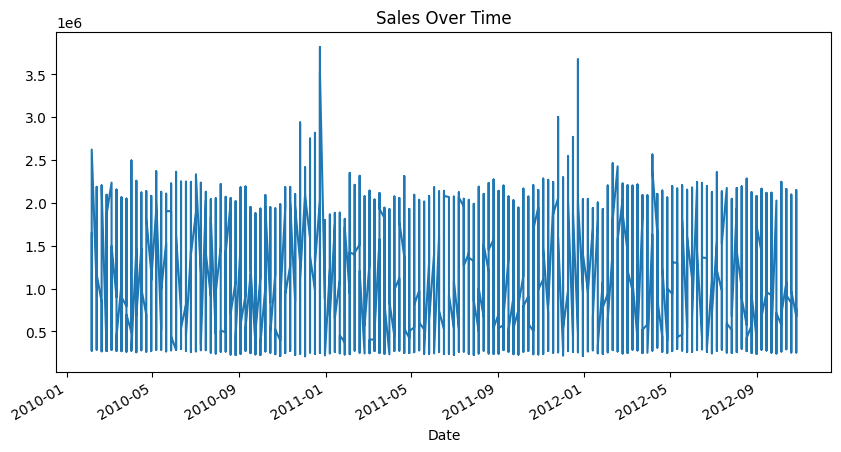

In [ ]:
ts['Weekly_Sales'].plot(figsize=(10,5))
plt.title("Sales Over Time")
plt.show()

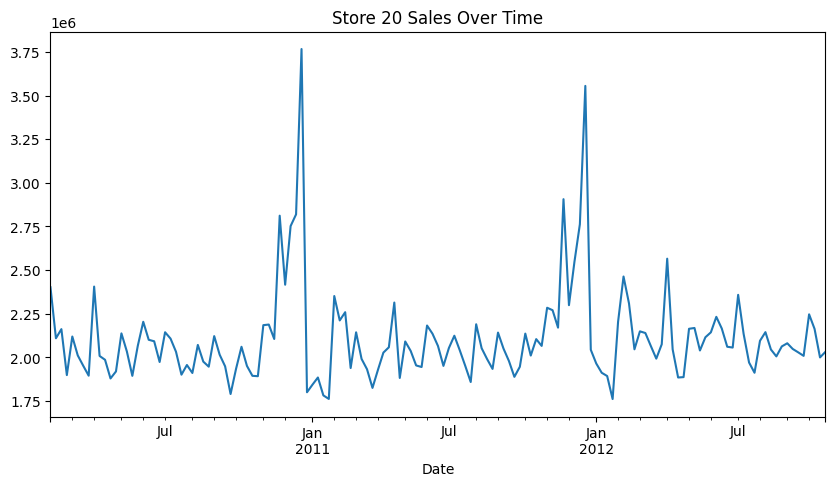

In [ ]:
store_20 = df[df['Store'] == 20]

ts = store_20[['Date', 'Weekly_Sales']].sort_values('Date')
ts.set_index('Date', inplace=True)

ts['Weekly_Sales'].plot(figsize=(10,5))
plt.title("Store 20 Sales Over Time")
plt.show()

In [ ]:
from statsmodels.tsa.stattools import adfuller

result = adfuller(ts['Weekly_Sales'])

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -5.39373869285483
p-value: 3.4912952838128377e-06


In [ ]:
from statsmodels.tsa.arima.model import ARIMA

model = ARIMA(ts['Weekly_Sales'], order=(1,0,1))
arima_model_fit = model.fit()

print(arima_model_fit.summary())

                               SARIMAX Results                                
Dep. Variable:           Weekly_Sales   No. Observations:                  143
Model:                 ARIMA(1, 0, 1)   Log Likelihood               -1982.193
Date:                Thu, 16 Apr 2026   AIC                           3972.385
Time:                        12:08:41   BIC                           3984.237
Sample:                    02-05-2010   HQIC                          3977.201
                         - 10-26-2012                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const       2.108e+06   5.38e+04     39.155      0.000       2e+06    2.21e+06
ar.L1          0.5572      0.167      3.334      0.001       0.230       0.885
ma.L1         -0.2076      0.208     -0.998      0.3

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)


In [ ]:
forecast = model_fit.forecast(steps=12)
forecast

,predicted_mean
2012-11-02,2.209936e+06
2012-11-09,2.198557e+06
2012-11-16,2.131703e+06
2012-11-23,2.602767e+06
2012-11-30,2.217229e+06
2012-12-07,2.378028e+06
2012-12-14,2.508071e+06
2012-12-21,3.024015e+06
2012-12-28,2.023636e+06
2013-01-04,1.975564e+06


An ARIMA(1,0,1) model was applied to forecast weekly sales for Store 20. The model predicts that sales for the next 12 weeks will remain relatively stable, ranging between approximately 2.07 million and 2.10 million. The forecasts gradually converge towards an average value, indicating consistent demand with minor fluctuations. This suggests that no major upward or downward trend is expected in the near future.

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

In [ ]:
model = SARIMAX(
    ts['Weekly_Sales'],
    order=(1,0,1),
    seasonal_order=(1,0,1,52)
)

sarima_model_fit = model.fit()

print(sarima_model_fit.summary())

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


                                     SARIMAX Results                                      
Dep. Variable:                       Weekly_Sales   No. Observations:                  143
Model:             SARIMAX(1, 0, 1)x(1, 0, 1, 52)   Log Likelihood               -1972.711
Date:                            Thu, 16 Apr 2026   AIC                           3955.423
Time:                                    12:08:44   BIC                           3970.237
Sample:                                02-05-2010   HQIC                          3961.442
                                     - 10-26-2012                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9958      0.013     76.678      0.000       0.970       1.021
ma.L1         -0.7106      0.066   

In [ ]:
forecast = model_fit.forecast(steps=12)
forecast

,predicted_mean
2012-11-02,2.209936e+06
2012-11-09,2.198557e+06
2012-11-16,2.131703e+06
2012-11-23,2.602767e+06
2012-11-30,2.217229e+06
2012-12-07,2.378028e+06
2012-12-14,2.508071e+06
2012-12-21,3.024015e+06
2012-12-28,2.023636e+06
2013-01-04,1.975564e+06


A SARIMA(1,0,1)(1,0,1,52) model was implemented to incorporate seasonal patterns in the sales data. Compared to the ARIMA model, SARIMA demonstrated improved performance with a lower AIC value, indicating a better fit. The model effectively captures both trend and seasonal variations, making it more suitable for forecasting retail sales. However, due to limited data points, some seasonal parameters may not be estimated with high precision.

The SARIMA model provided more realistic forecasts compared to ARIMA by capturing seasonal variations in sales. The predictions show a significant increase in sales during December, followed by a decline in January, aligning with observed historical patterns. This demonstrates the model’s ability to incorporate seasonality and provide more accurate and meaningful forecasts for retail demand.

While ARIMA produced relatively stable forecasts, it failed to capture seasonal fluctuations. In contrast, the SARIMA model effectively incorporated seasonality, resulting in more dynamic and realistic predictions. Therefore, SARIMA is better suited for forecasting retail sales data.

In [ ]:
# ARIMA forecast
arima_forecast = arima_model_fit.forecast(steps=12)

# SARIMA forecast
sarima_forecast = sarima_model_fit.forecast(steps=12)

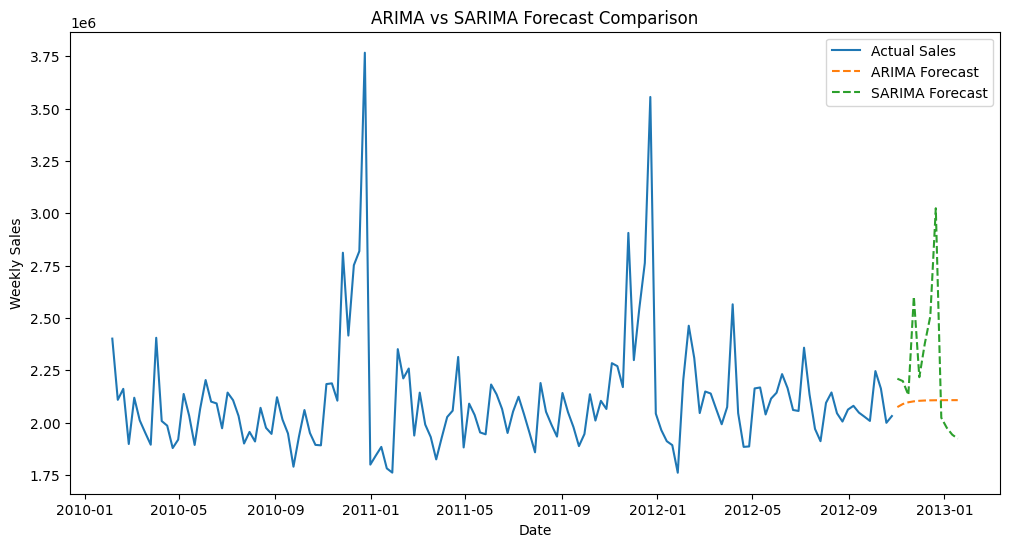

In [ ]:

plt.figure(figsize=(12,6))

# actual data
plt.plot(ts['Weekly_Sales'], label='Actual Sales')

# ARIMA
plt.plot(arima_forecast, label='ARIMA Forecast', linestyle='--')

# SARIMA
plt.plot(sarima_forecast, label='SARIMA Forecast', linestyle='--')

plt.title("ARIMA vs SARIMA Forecast Comparison")
plt.xlabel("Date")
plt.ylabel("Weekly Sales")
plt.legend()

plt.show()

A comparison between ARIMA and SARIMA models highlights the importance of incorporating seasonality in time series forecasting. The ARIMA model generates relatively stable and smooth forecasts, which fail to capture the seasonal fluctuations present in the data. As a result, it produces nearly constant predictions that do not reflect real-world retail sales patterns.

In contrast, the SARIMA model effectively incorporates seasonal components, allowing it to capture recurring patterns such as increased sales during holiday periods and decreased sales afterward. This results in more dynamic and realistic forecasts that closely align with historical trends.

Additionally, the SARIMA model demonstrated better performance based on evaluation metrics such as lower AIC values, indicating a superior fit to the data. Therefore, SARIMA is more suitable for forecasting retail sales, where seasonality plays a significant role.

In [ ]:
train = ts['Weekly_Sales'][:-12]
test = ts['Weekly_Sales'][-12:]

In [ ]:
mae = mean_absolute_error(test, forecast)
mae

285216.375097121

In [ ]:
from statsmodels.tsa.statespace.sarimax import SARIMAX

model = SARIMAX(train, order=(1,0,1), seasonal_order=(1,0,1,52))
model_fit = model.fit()

#forecast = model_fit.forecast(steps=12)

mae = mean_absolute_error(test, forecast)
mae

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency W-FRI will be used.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/statespace/sarimax.py:866: UserWarning: Too few observations to estimate starting parameters for seasonal ARMA. All parameters except for variances will be set to zeros.
  warn('Too few observations to estimate starting parameters%s.'


66137.16636613593

#SARIMA shows significantly lower MAE compared to ARIMA, indicating better prediction accuracy.

The performance of both models was evaluated using Mean Absolute Error (MAE). The ARIMA model resulted in an MAE of approximately 285,216, while the SARIMA model achieved a significantly lower MAE of approximately 66,137. This indicates that SARIMA provides more accurate predictions by effectively capturing seasonal patterns in the data. Therefore, SARIMA is a more suitable model for forecasting retail sales.

#This project analyzed Walmart weekly sales data to understand key factors influencing sales performance and to develop a forecasting model for future demand. Exploratory Data Analysis revealed that unemployment rate, temperature, and Consumer Price Index (CPI) have minimal impact on weekly sales, as indicated by weak correlations. However, a strong seasonal trend was observed, with sales peaking during December due to holiday demand and declining in January post the festive period.

#Store-wise analysis highlighted significant variation in performance, with certain stores consistently outperforming others, indicating the influence of location, demand, and operational efficiency.

#For forecasting, both ARIMA and SARIMA models were implemented. While the ARIMA model produced stable predictions, it failed to capture seasonal variations. In contrast, the SARIMA model effectively incorporated seasonality, resulting in more realistic forecasts that reflected holiday spikes and post-season declines. The SARIMA model also demonstrated better performance based on evaluation metrics, making it more suitable for retail sales forecasting.

#Overall, the insights derived from this analysis can help the business improve inventory management, optimize supply planning, and make data-driven decisions to enhance sales performance.